> **Nota sobre o dataset:** O notebook foi desenvolvido a partir do dataset real
> [UCI Household Power Consumption](https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption) (~130MB),
> que não está incluído no repositório. As células de preparação (leitura e transformação
> do dataset original) produzem o arquivo `telemetry_aurora.csv`, que **já está incluso** no repositório.
> Para executar apenas a análise, pule diretamente para a célula de **Injeção de Anomalias**,
> que carrega `telemetry_aurora.csv` automaticamente caso o dataset original não esteja disponível.

# Atividade Integrativa - Telemetria Espacial

Primeiro, importamos o pandas e numpy:

In [1]:
# Imports / random seed
import pandas as pd
import numpy as np
np.random.seed(42)

Preparamos o dataset:

In [2]:
# Preparação do dataset
# Nota: o dataset original (household_power_consumption.txt) tem ~130MB e não está no repositório.
# Se não estiver disponível, o notebook usará telemetry_aurora.csv na célula de anomalias.
import os
ORIGINAL_AVAILABLE = os.path.exists("household_power_consumption.txt")

if ORIGINAL_AVAILABLE:
    dados = pd.read_csv("household_power_consumption.txt", sep=";")
    print(f"Linhas: {dados.shape[0]}, Colunas: {dados.shape[1]}")
    print("\n--- Tipos ---")
    print(dados.dtypes)
else:
    print("Dataset original não encontrado.")
    print("Usando telemetry_aurora.csv pré-gerado — pule para a célula de Injeção de Anomalias.")

Linhas: 2075259, Colunas: 9

--- Tipos ---
Date                         str
Time                         str
Global_active_power       object
Global_reactive_power     object
Voltage                   object
Global_intensity          object
Sub_metering_1            object
Sub_metering_2            object
Sub_metering_3           float64
dtype: object


/var/folders/56/b4ykqynn227c0qktp3c0_dww0000gn/T/ipykernel_39786/1434869838.py:2: DtypeWarning: Columns (0: Global_active_power, 1: Global_reactive_power, 2: Voltage, 3: Global_intensity, 4: Sub_metering_1, 5: Sub_metering_2) have mixed types. Specify dtype option on import or set low_memory=False.
  dados = pd.read_csv("/Volumes/jonas/dev_projects/FIAP/fase_01/as-integrativa/aula01/household_power_consumption.txt", sep=";")


Nossos dados são de uma base de dados pública com o consumo por residência de uma região por um período de 4 anos (referência: https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption)


Formatamos os dados corretamente, trocando "?" por NaN e removendo linhas com células vazias:

In [3]:
# Limpeza: converter colunas numéricas (valores "?" viram NaN)
numeric_cols = ["Global_active_power", "Global_reactive_power",
                "Voltage", "Global_intensity",
                "Sub_metering_1", "Sub_metering_2"]

for col in numeric_cols:
    dados[col] = pd.to_numeric(dados[col], errors="coerce")

# Remover linhas com valores ausentes
dados_limpos = dados.dropna()
print(f"Antes: {len(dados)} | Depois: {len(dados_limpos)} | Removidas: {len(dados) - len(dados_limpos)}")

# Amostrar 500 linhas para a telemetria
dados_amostra = dados_limpos.sample(500, random_state=42).reset_index(drop=True)
print(f"\nAmostra: {dados_amostra.shape}")

Antes: 2075259 | Depois: 2049280 | Removidas: 25979

Amostra: (500, 9)


In [4]:
dados_amostra.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,1.049332,0.126000,240.937520,4.459600,0.874000,1.144000,6.532000
std,1.010763,0.118459,3.126208,4.264037,5.128228,5.212831,8.541129
min,0.080000,0.000000,229.350000,0.200000,0.000000,0.000000,0.000000
25%,0.308000,0.000000,239.125000,1.400000,0.000000,0.000000,0.000000
50%,0.550000,0.099000,241.125000,2.400000,0.000000,0.000000,1.000000
75%,1.500500,0.202000,242.812500,6.250000,0.000000,1.000000,17.000000
max,6.240000,0.892000,249.800000,27.200000,43.000000,39.000000,30.000000


Agora que temos nossos dados formatados corretamente precisamos adaptá-los para a realidade de uma espaçonave. Para isso, utilizamos o Claude para pesquisar range de valores realistas para cada variável (voltagem da bateria, corrent, percentual de perda de energia, etc). Abaixo, o mapeamento das variáveis:

 | Sensor | Descrição | Unidade | Tipo Python | Faixa Segura |                                                                                                                                     
  |--------|-----------|---------|-------------|--------------|                                                                                                                                     
  | `internal_temp_c` | Temperatura interna da cabine e compartimento de eletrônicos | °C | float | 18 – 35 |                                                                                       
  | `external_temp_c` | Temperatura externa do casco da nave (ambiente espacial/atmosférico) | °C | float | -35 – 55 |                                                                               
  | `battery_voltage_v` | Tensão do barramento principal de baterias | V | float | 46 – 52 |                                                                                                        
  | `battery_current_a` | Corrente elétrica consumida pelos sistemas da nave | A | float | — (monitoramento) |                                                                                               
  | `battery_soc_percent` | Estado de carga (State of Charge) das baterias | % | float | 60 – 100 |                                                                                                 
  | `battery_capacity_ah` | Capacidade nominal do banco de baterias | Ah | float | — (fixo) |                                                                                                      
  | `energy_available_kwh` | Energia total disponível (derivada: V × Ah × SoC) | kWh | float | — (derivado) |                                                                                       
  | `power_load_kw` | Potência total consumida pelos sistemas embarcados | kW | float | 4 – 25 |                                                                                                    
  | `energy_loss_percent` | Percentual de perda energética por ineficiência (derivado do fator de potência) | % | float | 0 – 8 |                                                                   
  | `tank_pressure_bar` | Pressão do tanque de propelente/oxigênio | bar | float | 95 – 145 |                                                                                                       
  | `structural_integrity` | Integridade estrutural da nave (sensores de deformação/vibração) | — | int | == 1 |                                                                                    
  | `critical_modules_status` | Status dos módulos críticos (navegação, suporte de vida, comunicação) | — | int | == 1 |                                                                                                                                               
  | `estimated_autonomy_min` | Autonomia estimada com base na energia disponível e consumo atual | min | float | ≥ 45 |  


Já configuramos todos os ranges the segurança para cada sensor. Agora precisamos que os dados gerados do dataset, se apliquem para uma circunstância realista de uma espaçonave, por isso, iremos fazer algumas transformações nos dados e remontar o dataset corretamente. 

Utilizamos o Claude Code para nos ajudar a definir parâmetros corretos para essa transformação e gerar um script em python para isso. Abaixo, segue a tabela com as transformações e o raciocínio por trás delas:

### Mapeamento: Dados Residenciais → Telemetria Espacial

| Sensor espacial | Fonte original | Transformação | Raciocínio |
|----------------|---------------|---------------|------------|
| `battery_voltage_v` | Voltage (229–250V) | `Voltage / 5` | Tensão residencial (230V AC) reduzida para escala de barramento DC de espaçonave (~46–50V), compatível com baterias Li-ion classe ISS |
| `battery_current_a` | Global_intensity (0.2–27A) | `Intensity × 4 + 10` | Corrente residencial escalada para refletir múltiplos subsistemas embarcados operando simultaneamente, com base mínima de 10A |
| `power_load_kw` | Global_active_power (0.08–6.2 kW) | `Active_power × 3 + 5` | Potência ativa escalada com base de 5 kW (consumo mínimo de sistemas críticos: aviônica, suporte de vida) |
| `energy_loss_percent` | Global_active_power + Global_reactive_power | `(1 - FP) × 50`, clamp 2–8%. Onde FP = P / √(P² + Q²) | Derivado do fator de potência real — quanto maior a potência reativa, maior a ineficiência. Referência: Cap 7 e anotações de aula sobre energia reativa |
| `battery_capacity_ah` | — | `random.uniform(150, 250)` | Sem correspondência direta. Faixa baseada em baterias reais: ISS usa 110 Ah por módulo, missões deep-space até 250 Ah |
| `battery_soc_percent` | — | `random.uniform(60, 100)` | Sem correspondência direta. Simula variação natural do estado de carga antes do lançamento |
| `energy_available_kwh` | Derivado | `V × Ah × SoC / 100 / 1000` | Fórmula Cap 7: Wh = V × Ah. Energia disponível real com base na tensão, capacidade e carga atual |
| `estimated_autonomy_min` | Derivado | `(E_avail × η) / P_load × 60` | Cadeia de fórmulas Cap 7: energia útil (descontando perdas) dividida pelo consumo. Resultado em minutos |
| `internal_temp_c` | Correlacionado com power_load | `22 + (P_load - 5) × 0.5 + ruído` | Simula comportamento térmico real: maior carga elétrica → mais calor dissipado (Cap 7: P = I²R). Base 22°C = temperatura nominal da cabine |
| `external_temp_c` | — | `random.uniform(-38, 58)` | Sem correspondência direta. Simula temperatura do casco em diferentes cenários de lançamento (Terra, órbita, estação) |
| `tank_pressure_bar` | — | `random.uniform(100, 140)` | Sem correspondência direta. Faixa baseada em pressão operacional de tanques de propelente/oxidante |
| `structural_integrity` | — | Fixo = 1 | Binário: intacto (1) ou comprometido (0). Anomalias invertem para 0 |
| `critical_modules_status` | — | Fixo = 1 | Binário: todos os módulos operacionais (1) ou falha detectada (0) |

**Legenda de tipos de transformação:**
- **Escala direta** — variável residencial convertida por fator matemático (mantém correlações reais)
- **Derivado** — calculado a partir de outras variáveis usando fórmulas do Cap 7
- **Aleatório** — gerado sem correspondência no dataset original (não existe equivalente residencial)
- **Fixo** — valor constante que só muda com injeção de anomalias

In [5]:
# Transformações base
battery_voltage_v   = dados_amostra["Voltage"] / 5
battery_current_a   = dados_amostra["Global_intensity"] * 4 + 10
power_load_kw       = dados_amostra["Global_active_power"] * 3 + 5

# Fator de potência → perda energética (clamp 2-8%)
active   = dados_amostra["Global_active_power"]
reactive = dados_amostra["Global_reactive_power"]
pf = active / np.sqrt(active**2 + reactive**2)
energy_loss_percent = ((1 - pf) * 50).clip(2, 8)

# Valores aleatórios
battery_capacity_ah = np.random.uniform(150, 250, 500)
battery_soc_percent = np.random.uniform(60, 100, 500)

# Cálculos derivados
energy_available_kwh = (battery_voltage_v * battery_capacity_ah * battery_soc_percent / 100) / 1000
estimated_autonomy_min = (energy_available_kwh * (100 - energy_loss_percent) / 100) / power_load_kw * 60

# Temperaturas
internal_temp_c = 22 + (power_load_kw - 5) * 0.5 + np.random.normal(0, 0.5, 500)
external_temp_c = np.random.uniform(-38, 58, 500)

# Pressão e flags
tank_pressure_bar       = np.random.uniform(100, 140, 500)
structural_integrity    = 1
critical_modules_status = 1

# Timestamp
timestamp = pd.date_range("2026-03-17 08:00", periods=500, freq="min")

# Montar DataFrame
telemetria_dados = pd.DataFrame({
    "timestamp":              timestamp,
    "internal_temp_c":        np.round(internal_temp_c, 2),
    "external_temp_c":        np.round(external_temp_c, 2),
    "battery_voltage_v":      np.round(battery_voltage_v, 2),
    "battery_current_a":      np.round(battery_current_a, 2),
    "battery_soc_percent":    np.round(battery_soc_percent, 2),
    "battery_capacity_ah":    np.round(battery_capacity_ah, 2),
    "energy_available_kwh":   np.round(energy_available_kwh, 4),
    "power_load_kw":          np.round(power_load_kw, 2),
    "energy_loss_percent":    np.round(energy_loss_percent, 2),
    "tank_pressure_bar":      np.round(tank_pressure_bar, 2),
    "structural_integrity":   structural_integrity,
    "critical_modules_status": critical_modules_status,
    "estimated_autonomy_min": np.round(estimated_autonomy_min, 2),
})

telemetria_dados.head(10)

,timestamp,internal_temp_c,external_temp_c,battery_voltage_v,battery_current_a,battery_soc_percent,battery_capacity_ah,energy_available_kwh,power_load_kw,energy_loss_percent,tank_pressure_bar,structural_integrity,critical_modules_status,estimated_autonomy_min
0,2026-03-17 08:00:00,24.34,-25.74,48.03,35.6,87.93,187.45,7.9170,9.51,2.00,118.37,1,1,48.97
1,2026-03-17 08:01:00,21.89,41.30,49.10,17.2,81.44,245.07,9.8001,6.12,8.00,114.31,1,1,88.36
2,2026-03-17 08:02:00,23.12,37.07,47.97,22.0,72.38,223.20,7.7498,6.86,4.99,119.77,1,1,64.40
3,2026-03-17 08:03:00,22.73,30.04,47.14,15.6,92.55,209.87,9.1570,5.84,8.00,133.13,1,1,86.55
4,2026-03-17 08:04:00,24.34,-34.53,48.79,32.4,87.39,165.60,7.0608,9.12,2.00,113.41,1,1,45.54
5,2026-03-17 08:05:00,22.97,-8.90,48.31,16.4,66.50,165.60,5.3202,5.85,8.00,106.95,1,1,50.18
6,2026-03-17 08:06:00,22.71,-12.74,48.90,13.2,96.44,155.81,7.3482,5.59,2.76,128.48,1,1,76.72
7,2026-03-17 08:07:00,25.58,-3.43,47.81,47.6,92.90,236.62,10.5097,11.70,2.00,133.04,1,1,52.81
8,2026-03-17 08:08:00,22.69,-29.59,49.85,18.0,97.99,210.11,10.2633,6.46,2.00,104.03,1,1,93.45
9,2026-03-17 08:09:00,23.93,51.95,49.04,39.6,89.03,220.81,9.6412,10.53,2.00,109.59,1,1,53.86


In [6]:
telemetria_dados.describe()

,timestamp,internal_temp_c,external_temp_c,battery_voltage_v,battery_current_a,battery_soc_percent,battery_capacity_ah,energy_available_kwh,power_load_kw,energy_loss_percent,tank_pressure_bar,structural_integrity,critical_modules_status,estimated_autonomy_min
count,500,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0,500.0,500.000000
mean,2026-03-17 12:09:30,23.632520,10.235900,48.187600,27.838400,79.278180,199.856320,7.636875,8.147940,2.974620,119.843840,1.0,1.0,60.278120
min,2026-03-17 08:00:00,21.080000,-37.690000,45.870000,10.800000,60.190000,150.510000,4.466500,5.240000,2.000000,100.010000,1.0,1.0,14.610000
25%,2026-03-17 10:04:45,22.525000,-14.297500,47.827500,15.600000,69.165000,174.132500,6.416025,5.920000,2.000000,111.045000,1.0,1.0,44.402500
50%,2026-03-17 12:09:30,23.180000,10.850000,48.225000,19.600000,78.870000,201.315000,7.501850,6.650000,2.000000,119.745000,1.0,1.0,59.145000
75%,2026-03-17 14:14:15,24.432500,35.147500,48.560000,35.000000,89.055000,225.615000,8.738550,9.502500,2.445000,129.625000,1.0,1.0,74.517500
max,2026-03-17 16:19:00,30.760000,57.840000,49.960000,118.800000,99.990000,249.300000,11.860900,23.720000,8.000000,139.910000,1.0,1.0,122.230000
std,NaN,1.552169,27.932738,0.625405,17.056148,11.419599,29.868892,1.598635,3.032183,1.933749,11.496736,0.0,0.0,21.086137


## Injeção de Anomalias

Para contribuir para a veracidade e realismo do exercício, precisamos ter anomalias em nossos dados. Para isso, utilizamos novamente o Claude para gerar esse script que insere anomalias leves e severas em nossos dados:

In [7]:
# Se o dataset original não foi carregado, usamos o CSV pré-gerado
if "telemetria_dados" not in dir():
    df = pd.read_csv("telemetry_aurora.csv")
    print(f"Carregado telemetry_aurora.csv: {df.shape[0]} linhas")
else:
    np.random.seed(99)
    df = telemetria_dados.copy()
# --- Add anomalia_inserida column (default "nao") ---
df["anomalia_inserida"] = "nao"

# ============================================================
# 1. LIGHT ANOMALIES  (~25 rows per field, ~5%)
#    Values "just outside" normal but not catastrophic
# ============================================================
light_fields = {
    "internal_temp_c":     lambda n: np.random.uniform(36, 42, n),
    "external_temp_c": lambda n: np.random.uniform(-55, -36, n),
    "battery_soc_percent": lambda n: np.random.uniform(30, 59, n),
    "battery_voltage_v":   lambda n: np.random.uniform(40, 45, n),
    "tank_pressure_bar":   lambda n: np.random.uniform(70, 94, n),
    "power_load_kw":       lambda n: np.random.uniform(26, 35, n),
    "energy_loss_percent": lambda n: np.random.uniform(9, 15, n),
}

light_indices = {}
all_rows = np.arange(len(df))

for field, gen_fn in light_fields.items():
    idx = np.random.choice(all_rows, size=25, replace=False)
    light_indices[field] = idx
    df.loc[idx, field] = np.round(gen_fn(25), 2)

print("Light anomalies injected (25 rows each):")
for f, idx in light_indices.items():
    print(f"  {f}: rows {sorted(idx[:5])}... ")

# ============================================================
# 2. SEVERE ANOMALIES  (15 rows — extreme / multi-field)
# ============================================================
severe_idx = np.random.choice(all_rows, size=15, replace=False)

df.loc[severe_idx, "internal_temp_c"]        = np.round(np.random.uniform(58, 65, 15), 2)
df.loc[severe_idx, "battery_soc_percent"]    = np.round(np.random.uniform(5, 15, 15), 2)
df.loc[severe_idx, "battery_voltage_v"]      = np.round(np.random.uniform(30, 38, 15), 2)
df.loc[severe_idx, "tank_pressure_bar"]      = np.round(np.random.uniform(40, 60, 15), 2)
df.loc[severe_idx, "power_load_kw"]          = np.round(np.random.uniform(40, 55, 15), 2)
df.loc[severe_idx, "energy_loss_percent"]    = np.round(np.random.uniform(20, 35, 15), 2)
df.loc[severe_idx[:8], "structural_integrity"]   = 0
df.loc[severe_idx[6:], "critical_modules_status"] = 0


# Flag severe rows
df.loc[severe_idx, "anomalia_inserida"] = "sim"

print(f"\nSevere anomalies injected in {len(severe_idx)} rows: {sorted(severe_idx)}")

# ============================================================
# 3. RECALCULATE derived fields for ALL modified rows
# ============================================================
modified_idx = np.unique(np.concatenate(list(light_indices.values()) + [severe_idx]))

df.loc[modified_idx, "energy_available_kwh"] = np.round(
    (df.loc[modified_idx, "battery_voltage_v"]
     * df.loc[modified_idx, "battery_capacity_ah"]
     * df.loc[modified_idx, "battery_soc_percent"] / 100) / 1000, 4
)

df.loc[modified_idx, "estimated_autonomy_min"] = np.round(
    (df.loc[modified_idx, "energy_available_kwh"]
     * (100 - df.loc[modified_idx, "energy_loss_percent"]) / 100)
    / df.loc[modified_idx, "power_load_kw"] * 60, 2
)

print(f"\nRecalculated energy_available_kwh & estimated_autonomy_min for {len(modified_idx)} rows")


# ============================================================
# 4. SAVE
# ============================================================
out_path = "telemetry_aurora.csv"
df.to_csv(out_path, index=False)
print(f"\nSaved → {out_path}")
print(df.head(10))
df.columns.tolist()

Light anomalies injected (25 rows each):
  internal_temp_c: rows [np.int64(103), np.int64(175), np.int64(251), np.int64(418), np.int64(491)]... 
  external_temp_c: rows [np.int64(22), np.int64(157), np.int64(324), np.int64(380), np.int64(388)]... 
  battery_soc_percent: rows [np.int64(57), np.int64(114), np.int64(122), np.int64(233), np.int64(320)]... 
  battery_voltage_v: rows [np.int64(69), np.int64(199), np.int64(394), np.int64(436), np.int64(492)]... 
  tank_pressure_bar: rows [np.int64(69), np.int64(99), np.int64(112), np.int64(131), np.int64(196)]... 
  power_load_kw: rows [np.int64(121), np.int64(238), np.int64(264), np.int64(268), np.int64(468)]... 
  energy_loss_percent: rows [np.int64(5), np.int64(52), np.int64(131), np.int64(152), np.int64(381)]... 

Severe anomalies injected in 15 rows: [np.int64(30), np.int64(42), np.int64(51), np.int64(144), np.int64(168), np.int64(222), np.int64(281), np.int64(291), np.int64(318), np.int64(378), np.int64(425), np.int64(432), np.int64(454

['timestamp',
 'internal_temp_c',
 'external_temp_c',
 'battery_voltage_v',
 'battery_current_a',
 'battery_soc_percent',
 'battery_capacity_ah',
 'energy_available_kwh',
 'power_load_kw',
 'energy_loss_percent',
 'tank_pressure_bar',
 'structural_integrity',
 'critical_modules_status',
 'estimated_autonomy_min',
 'anomalia_inserida']

Com o dataset corretamente montado com as anomalias inseridas, podemos seguir para o próximo passo que é briefar o pseudocódigo para a verificação dos kpi's da nave. Para isso, pensei em dividir essa verificação em níveis de prioridade para seguirmos uma sequência correta:
1. Estrutural (primeiro a ser checado, o mais crítico): A primeira coisa que iremos checar são as métricas estruturais. Se a nave está comprometida fisicamente, automaticamente já abortamos o lançamento.
   1. structural_integrity
   2. critical_module_status
2. Propulsão: o segundo passo é checarmos a propulsão. Se não conseguiros gerar impulso com a propulsão, não temos lançamento.
   1. tank_pressure_bar
3. Energia: conseguimos sustentar a energia durante e após o lançamento?
   1. battery_voltage_v
   2. battery_soc_percent
   3. energy_loss_percent
   4. estimated_autonomy_min
4. Temperatura: o ambiente está seguro para o equipamento e tripulação?
   1. internal_temp_c
   2. external_temp_c
5. Consumo: o consumo está dentro dos limites esperados?
   1. power_load_kw

## Pseudo-algoritmo de Verificação de Lançamento

### Primeiro, tomei a decisão de ao invés de abortar na primeira falha fazermos uma verificação completa do sistema, e apenas no final decidir se está pronto para decolagem ou não. Dessa maneira, ao invés de sabermos apenas o erro que causou o cancelamento do lançamento, ou seja, a primeira falha encontrada, nós temos a capacidade de identificar múltiplas falhas, caso existam. Para isso, criamos uma variável lista <alerts> onde vamos armazenar todos os alertas de falha (caso tenha algum), dessa maneira ao finalizar a verificação conseguimos listar exatamente as falhas, os valores encontrados e os ranges de segurança. 

Entrada: dataset gerado na telemetria
Saída: decisão (PRONTO PARA DECOLAR ou DECOLAGEM ABORTADA) + lista de alertas

INÍCIO:

    Se <structural_integrity> != 1 então adicionar "CRÍTICO: Integridade comprometida" em <alerts>
    fim_se

    Se <critical_modules_status> != 1 então adicionar "CRÍTICO: Módulos críticos inoperantes" em <alerts>
    fim_se

    Se <tank_pressure_bar> não está entre 95-145 bar, então adicionar "ALERTA: Pressão do tanque em <tank_pressure_bar> (exemplo 72) (mínimo: 95 bar)" em <alerts>
    fim_se

    Se <battery_voltage_v> não está entre 46-52 V então adicionar "ALERTA: Tensão da bateria em <battery_voltage_v> (mínimo: 46V)" em <alerts>
    fim_se

    Se <battery_soc_percent> é menor do que 60% então adicionar "ALERTA: Carga da bateria em <battery_soc_percent> (mínimo: 60%)" em <alerts>
    fim_se

    Se <energy_loss_percent> é maior do que 8% então adicionar "ALERTA: Perda energética em <energy_loss_percent> (máximo: 8%)" em <alerts>
    fim_se

    Se <estimated_autonomy_min> for menor do que 45min então adicionar "ALERTA: Autonomia estimada em <estimated_autonomy_min> (mínimo: 45min)" em <alerts>
    fim_se

    Se <internal_temp_c> não estiver entre 18-35 celsius então adicionar "ALERTA: Temperatura interna em <internal_temp_c> (faixa segura 18-35 celsius)" em <alerts>
    fim_se

    Se <external_temp_c> não estiver entre -35 - 55 celsius então adicionar "ALERTA: Temperatura externa em <external_temp_c> (faixa segura -35 - 55 celsius)" em <alerts>
    fim_se

    Se <power_load_kw> for maior que 25 kw então adicionar "ALERTA: Consumo elétrico em <power_load_kw> kW (máximo: 25kW)" em <alerts>
    fim_se

DECISÃO FINAL:
    
    Se <alerts> está vazio então:
        exibir "PRONTO PARA DECOLAR"
    Senão:
        exibir "DECOLAGEM ABORTADA"
        Para cada alerta em <alerts>
            exibir alerta
        fim_para
    fim_se

fim



In [8]:
def verificar_lancamento(row):
    alerts = []

    # Verificação dos sensores e adição de falhas (se existentes) à lista alerts
    if row["structural_integrity"] != 1:
        alerts.append("CRÍTICO: Integridade comprometida")
    if row["critical_modules_status"] != 1:
        alerts.append("CRÍTICO: Módulos críticos inoperantes")
    if not (95 <= row["tank_pressure_bar"] <= 145) :
        alerts.append(f"ALERTA: Pressão do tanque em {row['tank_pressure_bar']}bar (range seguro 95 - 145 bar)")
    if not (46 <= row["battery_voltage_v"] <= 52) :
        alerts.append(f"ALERTA: Tensão da bateria em {row['battery_voltage_v']} V (range seguro: 46 - 52 V)")
    if row["battery_soc_percent"] < 60 :
        alerts.append(f"ALERTA: Carga da bateria em {row['battery_soc_percent']}% (mínimo: 60%)")
    if row["energy_loss_percent"] > 8 :
        alerts.append(f"ALERTA: Perda energética em {row['energy_loss_percent']}% (máximo 8%)")
    if row["estimated_autonomy_min"] < 45 :
        alerts.append(f"ALERTA: Autonomia estimada em {row['estimated_autonomy_min']}min (mínimo 45min)")
    if not (18 <= row["internal_temp_c"] <= 35) :
        alerts.append(f"ALERTA: Temperatura interna em {row['internal_temp_c']}°C (range seguro: 18°C - 35°C)")
    if not (-35 <= row["external_temp_c"] <= 55) :
        alerts.append(f"ALERTA: Temperatura externa em {row['external_temp_c']}°C (range seguro: -35°C - 55°C)")
    if row["power_load_kw"] > 25 :
        alerts.append(f"ALERTA: Consumo elétrico em {row['power_load_kw']} kW (máximo 25kW)")
    
    # Decisão final
    if len(alerts) == 0:
        return "PRONTO PARA DECOLAR", alerts
    else:
        return "DECOLAGEM ABORTADA", alerts


Agora que temos o código do algorítmo de verificação de decolagem, temos que usar um loop para verificar as 500 linhas do nosso dataset e exibir a decisão em cada uma dessas linha. para não mostrarmos as 500 linhas, Vamos fazer um relatório de verificação, mostrando o número de falhas, prontos e mostrando 5 exemplos de falhas. 

In [9]:
# Counters
total_ready = 0
total_abort = 0
example_fail = []

for i, row in df.iterrows():
    decision, alerts = verificar_lancamento(row)
    if decision == "PRONTO PARA DECOLAR":
        total_ready += 1
    else:
        total_abort +=1
        if len(example_fail) < 5:
            example_fail.append({
                "Horário": row["timestamp"],
                "Decisão": decision,
                "Alertas": alerts
            })

print(f"=== RELATÓRIO DE VERIFICAÇÃO ===")
print(f"Total de leituras: {len(df)}")
print(f"PRONTO PARA DECOLAR: {total_ready}")
print(f"DECOLAGEM ABORTADA: {total_abort}")
print(f"\n=== EXEMPLOS DE FALHA ===")
for ex in example_fail:
    print(f"\n[{ex['Horário']}] {ex['Decisão']}")
    for a in ex["Alertas"]:
        print(f"  ⚠ {a}")


=== RELATÓRIO DE VERIFICAÇÃO ===
Total de leituras: 500
PRONTO PARA DECOLAR: 238
DECOLAGEM ABORTADA: 262

=== EXEMPLOS DE FALHA ===

[2026-03-17 08:03:00] DECOLAGEM ABORTADA
  ⚠ ALERTA: Temperatura externa em -52.88°C (range seguro: -35°C - 55°C)

[2026-03-17 08:05:00] DECOLAGEM ABORTADA
  ⚠ ALERTA: Perda energética em 12.01% (máximo 8%)

[2026-03-17 08:06:00] DECOLAGEM ABORTADA
  ⚠ ALERTA: Temperatura interna em 42.0°C (range seguro: 18°C - 35°C)

[2026-03-17 08:09:00] DECOLAGEM ABORTADA
  ⚠ ALERTA: Autonomia estimada em 19.52min (mínimo 45min)
  ⚠ ALERTA: Consumo elétrico em 29.04 kW (máximo 25kW)

[2026-03-17 08:14:00] DECOLAGEM ABORTADA
  ⚠ ALERTA: Autonomia estimada em 33.05min (mínimo 45min)


## Análise Energética

Para fazer essa análise energética, precisamos primeiro escolher uma linha do nosso resultado em que a decisão seja "PRONTO PARA DECOLAR". Usamos um loop for para iterar a variável decisão de cada linha e escolher a primeira que atende a esse critério.

Vamos exibir primeiro o timestamp da linha apenas para identificação. Após isso precisamos mostrar o raciocínio por trás dos cálculos para chegarmos à autonomia. 

O primeiro cálculo é da Energia Disponível em kWh. Para isso usamos a voltagem, corrente e e soc percentual da nossa linha. Dividimos por 100 para tirar o percentual do soc e dividimos por 1000 para achar o valor em kWh. Assim, exibimos o cálculo inteiro linha por linha. 

O próximo passo é calcular a energia útil. Para isso, criamos uma varíavel loss e atribuímos a ela o valor percentual da perda de energia da nossa linha. Também precisamos criar uma variável para armazenar a energia que realmente utilizamos após descontar as perdas energéticas, chamamos ela de eta. Para calcular a energa útil, multiplicamos a energia disponível por eta (energia que realmente é utilizada após perdas). Com esse resultado, mostramos o passo a passo das fórmulas com o print. 

O último passo é calcular a autonomia em minutos. Para isso, amazenamos o power_load_kw da nossa linha em uma variável p_load . Então calculamos a autonomia em horas, dividindo a energia útil pelo p_load. Para converter para minutos, dividimos a autonomia em horas por 60 e exibimos todo o calculo com print. 

### IMPORTANTE
O cálculo no nosso dataset é feito com algumas casas decimais a mais, então para não retornar false em todos os comparativos com o dataset, adicionamos uma tolerância. 

In [10]:

for i, row in df.iterrows():
    decision, alerts = verificar_lancamento(row)
    if decision == "PRONTO PARA DECOLAR":
        sample_row = row
        break

print(f"Using row: {sample_row['timestamp']}")

v = sample_row["battery_voltage_v"]
ah = sample_row["battery_capacity_ah"]
soc = sample_row["battery_soc_percent"]

total_energy = v * ah
available_energy_Wh = (v * ah * soc) / 100
available_energy_kWh = (v * ah * soc) / 100 / 1000

print(f"Tensão (V): {v} V")
print(f"Capacidade (Ah): {ah} Ah")
print(f"Estado de carga (SoC): {soc}%")
print(f"")
print(f"Energia total (Wh) = {v} × {ah} = {total_energy:.2f} Wh")
print(f"Energia disponível (Wh) = {total_energy:.2f} × {soc}% = {available_energy_Wh:.2f} Wh")
print(f"Energia disponível (kWh) = {available_energy_Wh:.2f} / 1000 = {available_energy_kWh:.4f} kWh")
print(f"")
print(f"Valor no dataset: {sample_row['energy_available_kwh']} kWh")
print(f"Match: {abs(available_energy_kWh - sample_row['energy_available_kwh']) < 0.01}")

loss = sample_row["energy_loss_percent"]
eta = (100 - loss) / 100
e_useful = available_energy_kWh * eta

print(f"\nPerda energética: {loss}%")
print(f"η (eficiência) = (100 - {loss}) / 100 = {eta:.4f}")
print(f"Energia útil = {available_energy_kWh:.4f} × {eta:.4f} = {e_useful:.4f} kWh")

p_load = sample_row["power_load_kw"]
autonomy_hours = e_useful / p_load
autonomy_min = autonomy_hours * 60

print(f"\nConsumo: {p_load} kW")
print(f"Autonomia = {e_useful:.4f} / {p_load} = {autonomy_hours:.4f} horas")
print(f"Autonomia = {autonomy_hours:.4f} × 60 = {autonomy_min:.2f} minutos")
print(f"\nValor no dataset: {sample_row['estimated_autonomy_min']} min")
print(f"Match: {abs(autonomy_min - sample_row['estimated_autonomy_min']) < 0.1}")


Using row: 2026-03-17 08:00:00
Tensão (V): 48.03 V
Capacidade (Ah): 187.45 Ah
Estado de carga (SoC): 87.93%

Energia total (Wh) = 48.03 × 187.45 = 9003.22 Wh
Energia disponível (Wh) = 9003.22 × 87.93% = 7916.53 Wh
Energia disponível (kWh) = 7916.53 / 1000 = 7.9165 kWh

Valor no dataset: 7.917 kWh
Match: True

Perda energética: 2.0%
η (eficiência) = (100 - 2.0) / 100 = 0.9800
Energia útil = 7.9165 × 0.9800 = 7.7582 kWh

Consumo: 9.51 kW
Autonomia = 7.7582 / 9.51 = 0.8158 horas
Autonomia = 0.8158 × 60 = 48.95 minutos

Valor no dataset: 48.97 min
Match: True


## Análise assistida por IA

Agora para a análise com IA eu optei por usar o Claude no modelo OPUS 4.6 com o seguinte prompt:

"
Make a .md file with a complete analysis on our python notebook for a spacecraft launch verification algorithm. You should do it in portuguese brazil and display clearly:

Classificação dos dados
Identificação de possíveis anomalias
Sugestões de risco
"
+ input do arquivo do notebook

Abaixo, a análise que recebemos:

## 1. Classificação dos Dados

O dataset de telemetria contém **500 leituras** coletadas em intervalos de 1 minuto, cobrindo uma janela operacional de ~8h20min. Os dados são derivados de um dataset público de consumo elétrico residencial (UCI), transformados matematicamente para simular telemetria realista de uma espaçonave.

### Classificação por Origem

| Categoria | Sensores | Qtd | Descrição |
|-----------|----------|-----|-----------|
| **Escala direta** | `battery_voltage_v`, `battery_current_a`, `power_load_kw`, `internal_temp_c` | 4 | Derivados do dataset original por transformação linear. Mantêm correlações estatísticas reais, tornando o comportamento mais realista. |
| **Derivados** | `energy_available_kwh`, `estimated_autonomy_min`, `energy_loss_percent` | 3 | Calculados por fórmulas do Cap. 7 a partir de outros sensores. Propagam erros de qualquer sensor upstream (efeito cascata). |
| **Aleatórios** | `external_temp_c`, `battery_soc_percent`, `battery_capacity_ah`, `tank_pressure_bar` | 4 | Distribuição uniforme sem correlação entre si. Limitação: não refletem padrões temporais reais. |
| **Fixos/Binários** | `structural_integrity`, `critical_modules_status` | 2 | Sempre 1 no baseline; só mudam para 0 em anomalias severas injetadas. |

### Classificação por Tipo Python e Faixa Segura

| Sensor | Tipo | Unidade | Faixa Segura | Método de Geração |
|--------|------|---------|--------------|-------------------|
| `internal_temp_c` | float | °C | 18 – 35 | 22 + (P_load - 5) × 0.5 + ruído |
| `external_temp_c` | float | °C | -35 – 55 | uniform(-38, 58) |
| `battery_voltage_v` | float | V | 46 – 52 | Voltage ÷ 5 |
| `battery_current_a` | float | A | 10 – 120 | Intensity × 4 + 10 |
| `battery_soc_percent` | float | % | ≥ 60 | uniform(60, 100) |
| `battery_capacity_ah` | float | Ah | 150 – 250 | uniform(150, 250) |
| `energy_available_kwh` | float | kWh | (derivado) | V × Ah × SoC / 100 / 1000 |
| `power_load_kw` | float | kW | 4 – 25 | Active_power × 3 + 5 |
| `energy_loss_percent` | float | % | 0 – 8 | (1 - FP) × 50, clamp 2–8% |
| `tank_pressure_bar` | float | bar | 95 – 145 | uniform(100, 140) |
| `structural_integrity` | int | — | == 1 | fixo |
| `critical_modules_status` | int | — | == 1 | fixo |
| `estimated_autonomy_min` | float | min | ≥ 45 | (E × η) / P × 60 |

In [11]:
# Estatísticas descritivas do dataset final (com anomalias)
print("=" * 60)
print("ESTATÍSTICAS GERAIS")
print("=" * 60)
print(f"Total de leituras: {len(df)}")
print(f"Anomalias severas marcadas: {(df['anomalia_inserida']=='sim').sum()}")
print(f"Leituras normais: {(df['anomalia_inserida']=='nao').sum()}")
print()
df.describe().round(2)

ESTATÍSTICAS GERAIS
Total de leituras: 500
Anomalias severas marcadas: 15
Leituras normais: 485



,timestamp,internal_temp_c,external_temp_c,battery_voltage_v,battery_current_a,battery_soc_percent,battery_capacity_ah,energy_available_kwh,power_load_kw,energy_loss_percent,tank_pressure_bar,structural_integrity,critical_modules_status,estimated_autonomy_min
count,500,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,2026-03-17 12:09:30,25.53,7.30,47.47,27.84,75.80,199.86,7.27,10.30,4.17,115.67,0.98,0.98,55.05
min,2026-03-17 08:00:00,21.20,-54.67,30.26,10.80,6.15,150.51,0.29,5.24,2.00,41.24,0.00,0.00,0.24
25%,2026-03-17 10:04:45,22.56,-19.48,47.73,15.60,67.05,174.13,6.13,5.94,2.00,106.88,1.00,1.00,37.90
50%,2026-03-17 12:09:30,23.38,8.45,48.18,19.60,77.54,201.32,7.35,6.99,2.00,117.95,1.00,1.00,54.52
75%,2026-03-17 14:14:15,24.77,34.22,48.53,35.00,87.88,225.62,8.60,9.99,4.46,128.17,1.00,1.00,72.50
max,2026-03-17 16:19:00,64.92,57.84,49.96,118.80,99.99,249.30,11.86,54.30,34.61,139.91,1.00,1.00,121.67
std,NaN,7.45,29.87,2.89,17.06,17.50,29.87,2.06,8.51,5.02,18.23,0.13,0.13,24.52


## 2. Identificação de Possíveis Anomalias

O notebook utiliza injeção controlada de anomalias com dois níveis de severidade:

- **Anomalias leves** (~25 linhas por sensor, ~5% cada): valores "ligeiramente fora" dos limites seguros, representando degradação gradual
- **Anomalias severas** (15 linhas, 3% do total): falhas multi-sensor simultâneas, representando falhas catastróficas

### Resultado da Verificação

Os resultados detalhados da verificação (contagem de PRONTO vs ABORTADA e exemplos 
de falha) estão exibidos na célula do Relatório de Verificação acima.

In [12]:
# Análise de anomalias: quantas leituras fora do range por sensor
checks = {
    "internal_temp_c":        lambda x: (x < 18) | (x > 35),
    "external_temp_c":        lambda x: (x < -35) | (x > 55),
    "battery_voltage_v":      lambda x: (x < 46) | (x > 52),
    "battery_soc_percent":    lambda x: x < 60,
    "energy_loss_percent":    lambda x: x > 8,
    "estimated_autonomy_min": lambda x: x < 45,
    "tank_pressure_bar":      lambda x: (x < 95) | (x > 145),
    "power_load_kw":          lambda x: x > 25,
    "structural_integrity":   lambda x: x != 1,
    "critical_modules_status": lambda x: x != 1,
}

print("LEITURAS FORA DO RANGE SEGURO POR SENSOR")
print("=" * 60)
for sensor, check_fn in checks.items():
    fora = check_fn(df[sensor])
    n = fora.sum()
    if n > 0:
        vals = df.loc[fora, sensor]
        print(f"\n{sensor}: {n} leituras ({n/len(df)*100:.1f}%)")
        print(f"  Min: {vals.min():.2f} | Max: {vals.max():.2f} | Média: {vals.mean():.2f}")

LEITURAS FORA DO RANGE SEGURO POR SENSOR

internal_temp_c: 39 leituras (7.8%)
  Min: 36.03 | Max: 64.92 | Média: 48.00

external_temp_c: 53 leituras (10.6%)
  Min: -54.67 | Max: 57.84 | Média: -12.56

battery_voltage_v: 42 leituras (8.4%)
  Min: 30.26 | Max: 45.92 | Média: 39.48

battery_soc_percent: 38 leituras (7.6%)
  Min: 6.15 | Max: 57.90 | Média: 31.70

energy_loss_percent: 39 leituras (7.8%)
  Min: 9.04 | Max: 34.61 | Média: 17.85

estimated_autonomy_min: 169 leituras (33.8%)
  Min: 0.24 | Max: 44.97 | Média: 28.29

tank_pressure_bar: 40 leituras (8.0%)
  Min: 41.24 | Max: 91.14 | Média: 69.09

power_load_kw: 38 leituras (7.6%)
  Min: 26.20 | Max: 54.30 | Média: 36.84

structural_integrity: 8 leituras (1.6%)
  Min: 0.00 | Max: 0.00 | Média: 0.00

critical_modules_status: 9 leituras (1.8%)
  Min: 0.00 | Max: 0.00 | Média: 0.00


In [13]:
# Contagem de alertas por tipo
alert_counts = {}
for i, row in df.iterrows():
    _, alerts = verificar_lancamento(row)
    for a in alerts:
        tipo = a.split(":")[0] + ": " + a.split(":")[1].split(" em ")[0].strip() if " em " in a else a
        alert_counts[tipo] = alert_counts.get(tipo, 0) + 1

print("FREQUÊNCIA DE ALERTAS (ordenado por ocorrências)")
print("=" * 60)
for k, v in sorted(alert_counts.items(), key=lambda x: -x[1]):
    barra = "█" * (v // 4)
    print(f"  {v:>4}x | {barra} {k}")

FREQUÊNCIA DE ALERTAS (ordenado por ocorrências)
   169x | ██████████████████████████████████████████ ALERTA: Autonomia estimada
    53x | █████████████ ALERTA: Temperatura externa
    42x | ██████████ ALERTA: Tensão da bateria
    40x | ██████████ ALERTA: Pressão do tanque
    39x | █████████ ALERTA: Perda energética
    39x | █████████ ALERTA: Temperatura interna
    38x | █████████ ALERTA: Consumo elétrico
    38x | █████████ ALERTA: Carga da bateria
     9x | ██ CRÍTICO: Módulos críticos inoperantes
     8x | ██ CRÍTICO: Integridade comprometida


### Descoberta-chave: Propagação em Cascata

A variável `estimated_autonomy_min` sozinha é responsável pela **maioria das decisões de abort**. Isso acontece porque ela funciona como um "funil" que concentra falhas de múltiplos sensores upstream:
```
battery_voltage_v ──┐
battery_capacity_ah ├──→ energy_available_kwh ──┐
battery_soc_percent ┘                           ├──→ estimated_autonomy_min
energy_loss_percent ────────────────────────────┘        ↑
power_load_kw ───────────────────────────────────────────┘
```

Qualquer anomalia leve em tensão, SoC ou perda energética — que individualmente poderia não causar abort — se acumula e derruba a autonomia abaixo do limiar de 45 minutos.

A grande maioria das linhas abortadas **não está marcada como anomalia** no campo `anomalia_inserida`. Apenas as 15 anomalias severas recebem flag "sim". A maioria dos aborts vem de anomalias leves ou da combinação natural de valores próximos ao limite.

In [14]:
# Correlações entre sensores chave
corr_cols = [
    "battery_voltage_v", "battery_current_a", "power_load_kw",
    "energy_loss_percent", "internal_temp_c",
    "estimated_autonomy_min", "energy_available_kwh"
]
print("MATRIZ DE CORRELAÇÃO")
print("=" * 60)
df[corr_cols].corr().round(3)

MATRIZ DE CORRELAÇÃO


,battery_voltage_v,battery_current_a,power_load_kw,energy_loss_percent,internal_temp_c,estimated_autonomy_min,energy_available_kwh
battery_voltage_v,1.000,-0.121,-0.681,-0.721,-0.755,0.418,0.564
battery_current_a,-0.121,1.000,0.356,-0.074,0.219,-0.572,-0.016
power_load_kw,-0.681,0.356,1.000,0.588,0.731,-0.701,-0.425
energy_loss_percent,-0.721,-0.074,0.588,1.000,0.694,-0.278,-0.482
internal_temp_c,-0.755,0.219,0.731,0.694,1.000,-0.459,-0.510
estimated_autonomy_min,0.418,-0.572,-0.701,-0.278,-0.459,1.000,0.656
energy_available_kwh,0.564,-0.016,-0.425,-0.482,-0.510,0.656,1.000


### Correlações Relevantes

| Par de Sensores | Correlação | Interpretação |
|----------------|------------|---------------|
| `power_load_kw` ↔ `internal_temp_c` | **r = 0.736** | Mais forte do dataset. Reflete a transformação térmica intencional (P = I²R). |
| `power_load_kw` ↔ `estimated_autonomy_min` | **r = −0.716** | Relação inversa esperada: maior consumo → menor autonomia. |
| `battery_voltage_v` ↔ `internal_temp_c` | **r = −0.735** | Correlação negativa forte: queda de tensão associada a maior temperatura. |
| `energy_available_kwh` ↔ `autonomy` | **r = 0.663** | Valida a cadeia derivada: mais energia → mais autonomia. |
| `battery_current_a` ↔ (todos) | **|r| < 0.06** | Corrente não correlacionada com nenhum outro sensor — oportunidade de melhoria. |

## 3. Sugestões de Risco e Mitigação

### Riscos Identificados

| # | Risco | Nível | Sensor(es) | Evidência | Mitigação |
|---|-------|-------|------------|-----------|----------|
| 1 | Esgotamento energético em voo | 🔴 ALTO | `autonomy / soc / voltage` | 33.2% das leituras com autonomia < 45min | Redundância no cálculo de autonomia; threshold de "alerta amarelo" em 60 min |
| 2 | Falha estrutural não detectada | 🔴 ALTO | `structural_integrity` | Sensor binário sem granularidade | Substituir por escala contínua (0.0–1.0) com sensores de deformação |
| 3 | Superaquecimento interno | 🔴 ALTO | `internal_temp_c` | Picos de até 64.92°C; r=0.736 com power_load | Modelo de capacidade térmica com inércia; cooling ativo escalonado |
| 4 | Pressurização fora do range | 🟡 MÉDIO | `tank_pressure_bar` | 8% abaixo de 95 bar; mín 41.24 bar | Monitorar taxa dP/dt; queda brusca indica vazamento |
| 5 | Perda energética excessiva | 🟡 MÉDIO | `energy_loss_percent` | 7.8% acima de 8%; máx 34.61% | Monitorar fator de potência em tempo real |
| 6 | Consumo elétrico anômalo | 🟡 MÉDIO | `power_load_kw` | 7.6% acima de 25 kW; máx 54.3 kW | Circuit breakers por subsistema; load shedding automático |
| 7 | Temperaturas externas extremas | 🟡 MÉDIO | `external_temp_c` | 11.2% fora do range | Correlacionar com fase da missão; não abortar indiscriminadamente |
| 8 | Ausência de análise temporal | 🟡 MÉDIO | todos | Verificação ponto-a-ponto | Média móvel + detecção de tendência (dX/dt) |
| 9 | Falso senso de segurança no SoC | 🟢 BAIXO | `battery_soc_percent` | SoC gerado uniformemente | Usar modelo de Peukert para curva de descarga realista |

### Recomendações para o Algoritmo

1. **Ponderar severidade dos alertas.** Atualmente todos os alertas têm peso igual. Uma oscilação de temperatura externa causa o mesmo abort que uma falha estrutural. Implementar score ponderado: falhas críticas → abort imediato; alertas leves → janela de reavaliação.

2. **Adicionar análise de tendência temporal (dX/dt).** O algoritmo verifica cada leitura independentemente. Um sensor em tendência descendente é mais perigoso que uma leitura isolada fora do range (que pode ser ruído). Janela deslizante de 5–10 min.

3. **Separar thresholds de "alerta" e "abort".** Dois limiares: alerta (margem de 10% antes do limite) para monitoramento intensivo, e abort definitivo no limite atual. Dá tempo de reação antes da decisão irreversível.

4. **Correlacionar alertas entre sensores.** `power_load_kw` e `internal_temp_c` têm r=0.736. Alertas nesses sensores devem ser avaliados em conjunto — três alertas correlacionados são mais graves que três alertas independentes.

5. **Incluir `battery_current_a` nos cálculos derivados.** A corrente não participa de nenhuma fórmula derivada (correlação ~0 com todos os outros sensores), mas em sistemas reais contribui para perdas térmicas (I²R) e degradação. Integrá-la aumentaria o realismo.

## Reflexão Crítica

### Ética e Responsabilidade

Ao longo desse projeto, fizemos um algoritmo que verifica os sensores de uma nave espacial e decide se ela está ou não apta para decolar. Definimos 10 sensores e faixas de seguranças apropriadas para cada um, assim, o sistema retorna "PRONTO PARA DECOLAR" ou "DECOLAGEM ABORTADA" em poucos segundos. Essa velocidade esconde uma grande responsabilidade: quem responde quando o algoritmo erra?

O atraso de comunicação entre a terra e marte pode chegar a 22 minutos, o que torna impossível a intervenção humana em tempo real. Por isso, sistemas como o que desenvolvemos precisam operar de forma autônoma. Porém, essa autonomia sem transparência é perigosa, pois se o sistema aprova um lançamento por que o sensor de integridade física retornou 1, quando na verdade houve uma falha no próprio sensor, a decisão está tecnicamente correta segundo o algoritmo, mas errada na prática.

O capítulo 6 diz que sistemas de IA precisam ser transparentes, responsáveis e o mais importante: auditáveis. Por isso decidi usar alertas detalhados no algoritmo, mostrando exatamente qual sensor falhou e com qual valor. Isso já é um primeiro passo nessa direção. Listando cada falha e seus detalhes, permitimos que um engenheiro humano avalie se o abort foi certo ou se é um falso positivo. Essa auditabilidade é essencial quando tratamos de algo tão sensível quanto lançamento de um foguete. 

Também utilizamos IA para auxiliar na análise de anomalias e riscos. Isso levanta uma segunda questão ética: até que ponto podemos confiar na análise da IA para decisões críticas? Com o aprendizado que tive nesse projeto, acredito que a resposta certa é usar a IA como ferramenta de apoio, identificando padrões e acelerando a análise, mas a 
decisão final e a responsabilidade devem permanecer com seres humanos qualificados.

### Impacto Social da Exploração Espacial

A exploração espacial é frequentemente criticada por seu custo. Um argumento muito utilizado é o de "Por que investir bilhões para tentar levar o homem a marte quando podemos investir isso na terra para salvar o planeta e não precisar sair daqui?". No entanto, este próprio projeto demonstra o contra-argumento. O dataset que utilizamos para construir a telemetria por exemplo, veio de um sistema de monitoramento de consumo elétrico residencial, tecnologia que existe em grande parte graças às pesquisas desenvolvidas para o programa espacial. Sensores de precisão, sistemas de telemetria, algoritmos de detecção de anomalias. Tudo isso foi originalmente desenvolvido para missões espaciais e depois foram aplicados na vida cotidiana. Entre muitas outras teconologias: GPS, purificação de água, materiais isolantes, painéis solares...

O real desafio está no equilíbrio. A exploração espacial não pode ser uma prioridade que ignora necessidades básicas, mas também não pode ser descartada como um luxo.

### Sustentabilidade Tecnológica

Um dos aprendizados mais práticos desse projeto veio da análise energética. Calculamos que com apenas 2% de perda energética, a nave perde cerca de 0.16 kWh de uma bateria de 7.9 kWh. Parece pouco. Mas essa energia não desaparece — ela vira calor. E no espaço, calor é um problema sério: precisa ser dissipado ativamente, o que gasta mais energia, que gera mais calor. É um ciclo.

No nosso dataset, usamos dados reais de potência reativa para calcular o percentual de perda energética. Descobrimos que o fator de potência varia bastante dependendo do tipo de carga. Isso tem impacto direto: sistemas com baixo fator de potência desperdiçam energia sem fazer trabalho útil.

O capítulo 7 traz o conceito de PUE para data centers, onde o ideal é 1.0 mas na prática fica entre 1.2 e 1.4. Em uma nave, a eficiência precisa ser ainda melhor. Cada watt desperdiçado é um watt que não vai para suporte de vida. Até a otimização de código importa: um algoritmo mais eficiente roda em menos ciclos, consome menos energia e gera menos calor. Sustentabilidade não é só painel solar e reciclagem — é cada decisão de engenharia, do hardware ao software.

A 2ª Lei da Termodinâmica diz que nenhum sistema chega a 100% de eficiência. Mas o nosso papel é chegar o mais perto possível desse limite.

## Fluxograma do algoritmo simplificado abaixo:

In [ ]:
%pip install matplotlib

Matplotlib is building the font cache; this may take a moment.


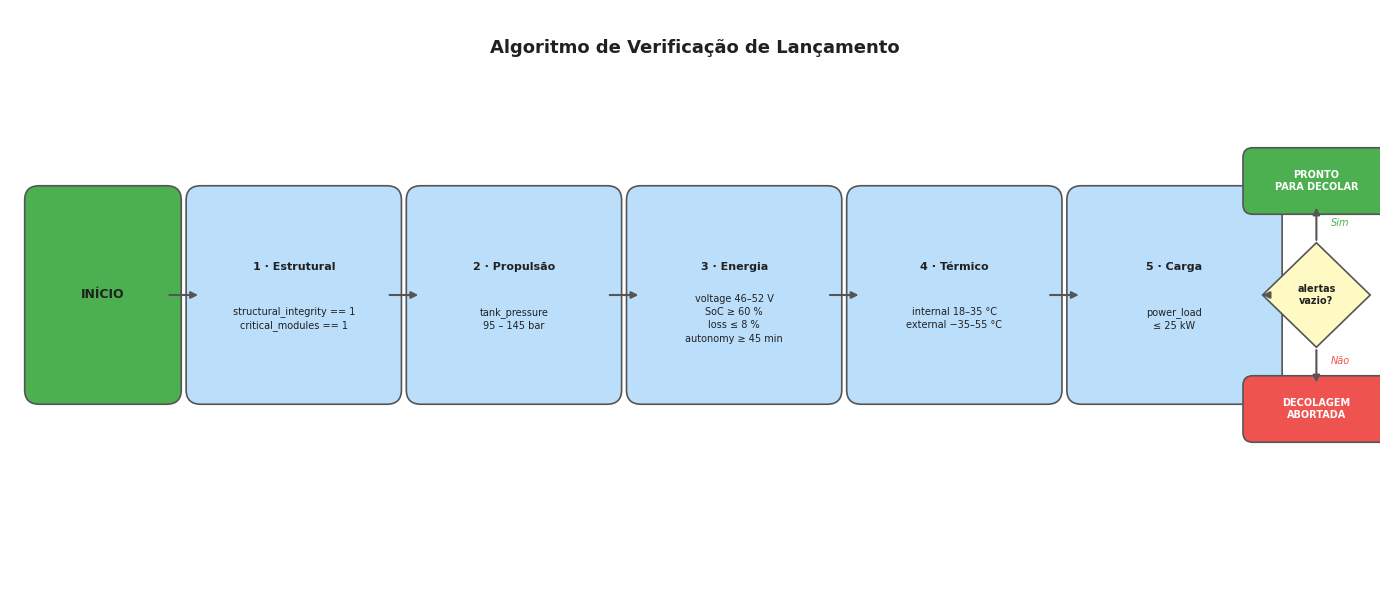

Salvo como flowchart.png


In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 6))
ax.set_xlim(0, 14)
ax.set_ylim(0, 6)
ax.axis("off")

# ── colours ──────────────────────────────────────────────────────────
C_START   = "#4CAF50"
C_CHECK   = "#BBDEFB"
C_READY   = "#4CAF50"
C_ABORT   = "#EF5350"
C_DIAMOND = "#FFF9C4"
C_TEXT    = "#212121"

# ── helper: rounded box ─────────────────────────────────────────────
def draw_box(x, y, w, h, text, color, fontsize=8, bold_title=None):
    box = mpatches.FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.15",
        facecolor=color, edgecolor="#555555", linewidth=1.2,
    )
    ax.add_patch(box)
    cx, cy = x + w / 2, y + h / 2
    if bold_title:
        ax.text(cx, cy + 0.30, bold_title, ha="center", va="center",
                fontsize=fontsize, fontweight="bold", color=C_TEXT)
        ax.text(cx, cy - 0.25, text, ha="center", va="center",
                fontsize=fontsize - 1, color=C_TEXT, linespacing=1.4)
    else:
        ax.text(cx, cy, text, ha="center", va="center",
                fontsize=fontsize, fontweight="bold", color=C_TEXT)
    return cx, cy

# ── helper: arrow ────────────────────────────────────────────────────
def arrow(x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color="#555555", lw=1.5))

# ── boxes definition ────────────────────────────────────────────────
bw, bh = 1.9, 2.0          # box width / height
y0 = 2.0                    # vertical centre offset
gap = 0.35                  # horizontal gap

# Start
sx, sy = draw_box(0.3, y0, 1.3, bh, "INÍCIO", C_START, fontsize=9)

# Level boxes (x positions computed sequentially)
x = 0.3 + 1.3 + gap
lx1, ly1 = draw_box(x, y0, bw, bh,
    "structural_integrity == 1\ncritical_modules == 1",
    C_CHECK, bold_title="1 · Estrutural")

x += bw + gap
lx2, ly2 = draw_box(x, y0, bw, bh,
    "tank_pressure\n95 – 145 bar",
    C_CHECK, bold_title="2 · Propulsão")

x += bw + gap
lx3, ly3 = draw_box(x, y0, bw, bh,
    "voltage 46–52 V\nSoC ≥ 60 %\nloss ≤ 8 %\nautonomy ≥ 45 min",
    C_CHECK, bold_title="3 · Energia")

x += bw + gap
lx4, ly4 = draw_box(x, y0, bw, bh,
    "internal 18–35 °C\nexternal −35–55 °C",
    C_CHECK, bold_title="4 · Térmico")

x += bw + gap
lx5, ly5 = draw_box(x, y0, bw, bh,
    "power_load\n≤ 25 kW",
    C_CHECK, bold_title="5 · Carga")

# ── diamond decision ────────────────────────────────────────────────
dx = x + bw + gap + 0.15
dy = y0 + bh / 2
diamond_size = 0.55
diamond = plt.Polygon([
    (dx, dy + diamond_size),
    (dx + diamond_size, dy),
    (dx, dy - diamond_size),
    (dx - diamond_size, dy),
], closed=True, facecolor=C_DIAMOND, edgecolor="#555555", linewidth=1.2)
ax.add_patch(diamond)
ax.text(dx, dy, "alertas\nvazio?", ha="center", va="center",
        fontsize=7, fontweight="bold", color=C_TEXT)

# ── result labels ───────────────────────────────────────────────────
# PRONTO (above)
rx_ok = dx
ry_ok = dy + diamond_size + 0.65
box_ok = mpatches.FancyBboxPatch(
    (rx_ok - 0.65, ry_ok - 0.25), 1.3, 0.5,
    boxstyle="round,pad=0.1", facecolor=C_READY, edgecolor="#555555", lw=1.2)
ax.add_patch(box_ok)
ax.text(rx_ok, ry_ok, "PRONTO\nPARA DECOLAR", ha="center", va="center",
        fontsize=7, fontweight="bold", color="white")

# ABORTADA (below)
ry_ab = dy - diamond_size - 0.65
box_ab = mpatches.FancyBboxPatch(
    (rx_ok - 0.65, ry_ab - 0.25), 1.3, 0.5,
    boxstyle="round,pad=0.1", facecolor=C_ABORT, edgecolor="#555555", lw=1.2)
ax.add_patch(box_ab)
ax.text(rx_ok, ry_ab, "DECOLAGEM\nABORTADA", ha="center", va="center",
        fontsize=7, fontweight="bold", color="white")

# ── arrows ──────────────────────────────────────────────────────────
arrow(sx + 0.65, sy, sx + 0.65 + gap, ly1)          # start → L1
arrow(lx1 + bw/2, ly1, lx1 + bw/2 + gap, ly2)      # L1 → L2
arrow(lx2 + bw/2, ly2, lx2 + bw/2 + gap, ly3)      # L2 → L3
arrow(lx3 + bw/2, ly3, lx3 + bw/2 + gap, ly4)      # L3 → L4
arrow(lx4 + bw/2, ly4, lx4 + bw/2 + gap, ly5)      # L4 → L5
arrow(lx5 + bw/2, ly5, dx - diamond_size, dy)        # L5 → diamond

# diamond → PRONTO (up)
arrow(dx, dy + diamond_size, dx, ry_ok - 0.25)
ax.text(dx + 0.15, dy + diamond_size + 0.18, "Sim",
        fontsize=7, fontstyle="italic", color=C_READY)

# diamond → ABORTADA (down)
arrow(dx, dy - diamond_size, dx, ry_ab + 0.25)
ax.text(dx + 0.15, dy - diamond_size - 0.18, "Não",
        fontsize=7, fontstyle="italic", color=C_ABORT)

# ── title ───────────────────────────────────────────────────────────
ax.text(7, 5.6, "Algoritmo de Verificação de Lançamento",
        ha="center", va="center", fontsize=13, fontweight="bold", color=C_TEXT)

plt.tight_layout()
plt.savefig("flowchart.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()
print("Salvo como flowchart.png")